Loading reference: air ref.txt

=== Processing sample: ref1_904um 1.txt, d = 904.0 µm ===
  Saved optical constants to: optical_constants_ref1_904um_1.csv

=== Processing sample: ref2_680um 1.txt, d = 680.0 µm ===
  Saved optical constants to: optical_constants_ref2_680um_1.csv

=== Processing sample: exp_1 555um 1.txt, d = 555.0 µm ===
  Saved optical constants to: optical_constants_exp_1_555um_1.csv

=== Processing sample: exp_2 900um 3.txt, d = 900.0 µm ===
  Saved optical constants to: optical_constants_exp_2_900um_3.csv

=== Processing sample: exp_3 829um 1.txt, d = 829.0 µm ===
  Saved optical constants to: optical_constants_exp_3_829um_1.csv


C:\Users\ASUS\AppData\Local\Temp\ipykernel_23960\659019250.py:73: RuntimeWarning: invalid value encountered in divide
  n = 1 + c * phi / (omega * d)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_23960\659019250.py:73: RuntimeWarning: divide by zero encountered in divide
  n = 1 + c * phi / (omega * d)



Summary for all samples saved to: optical_constants_all_samples.csv


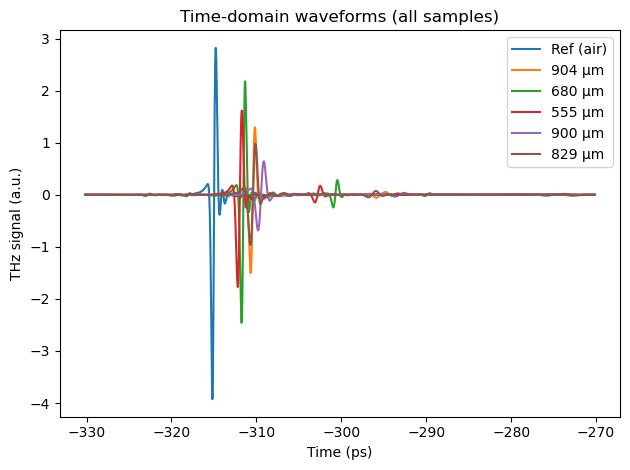

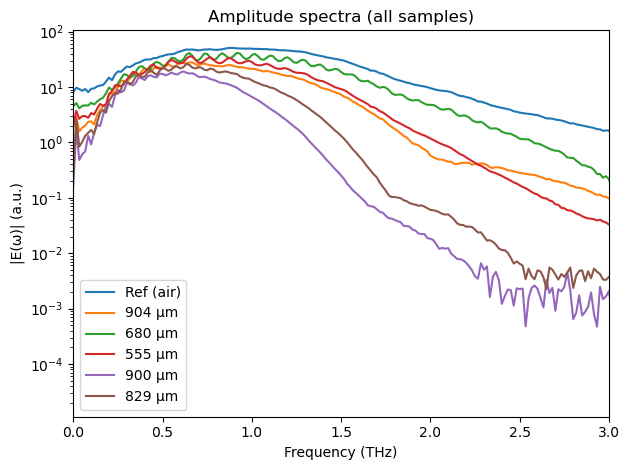

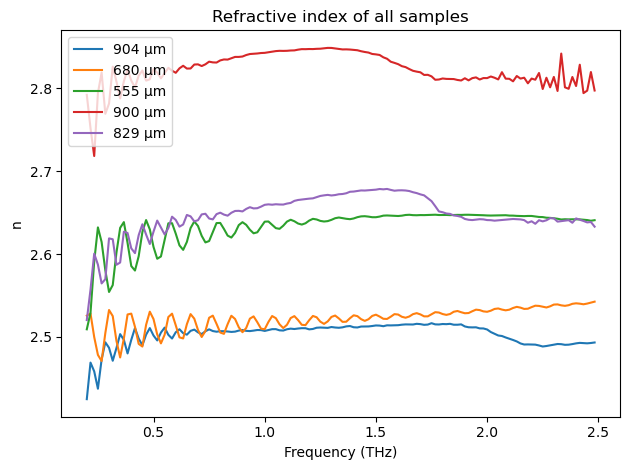

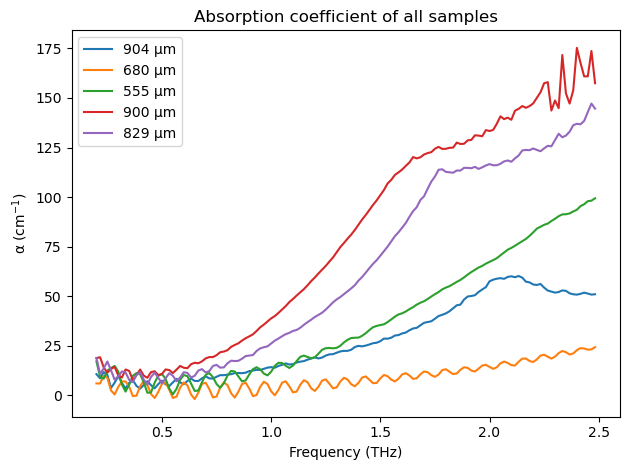

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ========================
#  用户需要修改的部分
# ========================

# 数据所在文件夹
base = Path(".")   # TODO: 改成你的路径

# 参考波形文件名
ref_file_name = "air ref.txt"             # TODO: 如有不同名称在这里改

# 样品：文件名 -> 厚度(µm)
samples = {
    "ref1_904um 1.txt" : 904.0,
    "ref2_680um 1.txt" : 680.0,
    "exp_1 555um 1.txt": 555.0,
    "exp_2 900um 3.txt": 900.0,
    "exp_3 829um 1.txt": 829.0,
    # 可以继续往下加：
    # "exp_2 900um 2.txt": 900.0,
    # "exp_3 829um 2.txt": 829.0,
}

# 频率范围设置
F_MIN = 0.2   # THz
F_MAX = 2.5   # THz
REF_AMP_RATIO_MIN = 0.01  # 参考谱强度下限（相对最大值）

# ========================
#  公共函数
# ========================

c = 3e8  # m/s


def load_time_domain(path: Path):
    """读取 Menlo txt 时域数据"""
    data = np.loadtxt(path, comments="#")
    t_ps = data[:, 0]
    E = data[:, 1]
    return t_ps, E


def time_to_freq(t_ps, E):
    """时域 -> 频域（rFFT）"""
    t_s = t_ps * 1e-12
    dt = np.mean(np.diff(t_s))
    freqs = np.fft.rfftfreq(len(E), dt)  # Hz
    spectrum = np.fft.rfft(E)
    return freqs / 1e12, spectrum        # THz, complex spectrum


def extract_n_alpha(f_THz, S_ref, S_sam, thickness_um):
    """
    从参考和样品频谱提取 n(f), alpha(f)
    返回：f_use, n_use, alpha_use(cm^-1)
    """
    f_Hz = f_THz * 1e12
    omega = 2 * np.pi * f_Hz
    d = thickness_um * 1e-6  # m

    # 幅度 和 相位 的传输函数
    H_amp = S_sam / S_ref          # 振幅比
    H_phase = S_ref / S_sam        # 相位用反比，保证 n > 1

    phi = np.unwrap(np.angle(H_phase))

    # 折射率
    n = 1 + c * phi / (omega * d)
    n[0] = np.nan  # 0 频点无意义

    # 吸收系数
    magH = np.abs(H_amp)
    n_safe = np.where(n > 0, n, np.nan)
    alpha = (2 / d) * (np.log(4 * n_safe / (n_safe + 1) ** 2) - np.log(magH))
    alpha_cm = alpha / 100.0

    # 频段 & SNR 筛选
    mask = (
        (f_THz > F_MIN)
        & (f_THz < F_MAX)
        & (np.abs(S_ref) > REF_AMP_RATIO_MIN * np.max(np.abs(S_ref)))
        & np.isfinite(n_safe)
        & np.isfinite(alpha_cm)
    )

    return f_THz[mask], n[mask], alpha_cm[mask]


# ========================
#  主流程
# ========================

def main():
    # ---- 1. 读取参考并 FFT ----
    ref_path = base / ref_file_name
    print(f"Loading reference: {ref_path}")
    t_ref_ps, E_ref = load_time_domain(ref_path)
    f_ref_THz, S_ref = time_to_freq(t_ref_ps, E_ref)

    # 用于“所有样品画在一张图”的数据缓存
    time_curves = []   # (label, t_ps, E)
    fft_curves = []    # (label, f_THz, |S|)
    n_curves = []      # (label, f_use, n_use)
    alpha_curves = []  # (label, f_use, alpha_use)

    # 把参考先放进去
    time_curves.append(("Ref (air)", t_ref_ps, E_ref))
    fft_curves.append(("Ref (air)", f_ref_THz, np.abs(S_ref)))

    # 总表
    summary_dict = {"f_THz": None}

    # ---- 2. 处理各个样品 ----
    for fname, thickness in samples.items():
        print(f"\n=== Processing sample: {fname}, d = {thickness} µm ===")
        sam_path = base / fname

        t_sam_ps, E_sam = load_time_domain(sam_path)

        # 截到与参考相同长度（防止长度不同）
        N = min(len(E_ref), len(E_sam))
        t_ref = t_ref_ps[:N]
        E_ref_trunc = E_ref[:N]
        t_sam = t_sam_ps[:N]
        E_sam_trunc = E_sam[:N]

        # FFT
        f_sam_THz, S_sam = time_to_freq(t_sam, E_sam_trunc)

        label = f"{thickness:.0f} µm"

        # ---- 2.1 存入“所有样品叠加图”的数据 ----
        time_curves.append((label, t_sam, E_sam_trunc))
        fft_curves.append((label, f_sam_THz, np.abs(S_sam)))

        # ---- 2.2 计算 n & α ----
        f_use, n_use, alpha_use = extract_n_alpha(
            f_ref_THz, S_ref, S_sam, thickness_um=thickness
        )
        n_curves.append((label, f_use, n_use))
        alpha_curves.append((label, f_use, alpha_use))

        # ---- 2.3 导出每个样品的 CSV ----
        safe_name = fname.replace(" ", "_").replace(".txt", "")
        csv_path = base / f"optical_constants_{safe_name}.csv"
        df_single = pd.DataFrame(
            {"f_THz": f_use, "n": n_use, "alpha_cm^-1": alpha_use}
        )
        df_single.to_csv(csv_path, index=False)
        print(f"  Saved optical constants to: {csv_path}")

        # ---- 2.4 写入总表 ----
        if summary_dict["f_THz"] is None:
            summary_dict["f_THz"] = f_use
        summary_dict[f"n_{safe_name}"] = n_use
        summary_dict[f"alpha_{safe_name}_cm^-1"] = alpha_use

    # ---- 3. 汇总画图：全部 Time domain ----
    plt.figure()
    for label, t_ps, E in time_curves:
        plt.plot(t_ps, E, label=label)
    plt.xlabel("Time (ps)")
    plt.ylabel("THz signal (a.u.)")
    plt.title("Time-domain waveforms (all samples)")
    plt.legend()
    plt.tight_layout()

    # 如果只想看主峰附近，可以手动加 xlim：
    # plt.xlim(-320, -305)

    # ---- 4. 汇总画图：全部 FFT 幅度谱 ----
    plt.figure()
    for label, f_THz, amp in fft_curves:
        plt.semilogy(f_THz, amp, label=label)
    plt.xlabel("Frequency (THz)")
    plt.ylabel("|E(ω)| (a.u.)")
    plt.title("Amplitude spectra (all samples)")
    plt.xlim(0, 3)
    plt.legend()
    plt.tight_layout()

    # ---- 5. 汇总画图：全部 n(f) ----
    plt.figure()
    for label, f_use, n_use in n_curves:
        plt.plot(f_use, n_use, label=label)
    plt.xlabel("Frequency (THz)")
    plt.ylabel("n")
    plt.title("Refractive index of all samples")
    plt.legend()
    plt.tight_layout()

    # ---- 6. 汇总画图：全部 α(f) ----
    plt.figure()
    for label, f_use, alpha_use in alpha_curves:
        plt.plot(f_use, alpha_use, label=label)
    plt.xlabel("Frequency (THz)")
    plt.ylabel("α (cm$^{-1}$)")
    plt.title("Absorption coefficient of all samples")
    plt.legend()
    plt.tight_layout()

    # ---- 7. 输出总表 ----
    df_all = pd.DataFrame(summary_dict)
    summary_path = base / "optical_constants_all_samples.csv"
    df_all.to_csv(summary_path, index=False)
    print(f"\nSummary for all samples saved to: {summary_path}")

    plt.show()


if __name__ == "__main__":
    main()
